In [99]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import random
import warnings

# Suppress sklearn warnings about multi-class classification with many species
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.metrics._classification')

In [100]:
#--- Random Seeding + DEVICE Checking ---
def set_seed(seed):
    """
    Set all random seeds for reproducibility.
    This ensures consistent data splits and weight initialization.
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    # For deterministic behavior (slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Initial seed setup
set_seed(8)

# check what DEVICE we're using
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"Using DEVICE: CUDA")
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print(f"Using DEVICE: MPS (Apple Silicon)")
else:
    DEVICE = torch.device('cpu')
    print(f"Using DEVICE: CPU")

Using DEVICE: CUDA


In [101]:
#--- Creating a custom dataset class ---
class SharkFluorescenceDataset(Dataset):
    def __init__(self, csv_path, augment=False, mean=None, std=None):
        # Load CSV
        self.data = pd.read_csv(csv_path)
        
        # Extract species names (labels) from first column
        self.species = self.data.iloc[:, 0].values
        
        # Extract fluorescence values (all columns except first)
        # Shape: (num_samples, num_time_steps)
        self.fluorescence = self.data.iloc[:, 1:].values.astype(np.float32)

        # Normalization
        if mean is None or std is None:
            # Calculate mean and std from this data (for training set)
            self.mean = self.fluorescence.mean()
            self.std = self.fluorescence.std()
        else:
            # Use provided mean and std (for val/test sets)
            self.mean = mean
            self.std = std
        
        # Apply normalization: (x - mean) / std
        self.fluorescence = (self.fluorescence - self.mean) / self.std
        
        # Encode species names to numeric labels
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.species)
        
        self.num_classes = len(self.label_encoder.classes_)
        self.augment = augment
        
        print(f"Dataset loaded: {len(self.labels)} samples")
        print(f"Number of species: {self.num_classes}")
        print(f"Time series length: {self.fluorescence.shape[1]}")
        print(f"Augmentation: {'Enabled' if augment else 'Disabled'}")
        print(f"Data normalized with mean={self.mean:.6f}, std={self.std:.6f}")
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # Get fluorescence values and add channel dimension
        # Shape: (1, num_time_steps) - 1D conv expects (channels, length)
        x = torch.FloatTensor(self.fluorescence[idx]).unsqueeze(0)

        # Apply augmentation if enabled
        if self.augment:
            # Small random noise
            noise = torch.randn_like(x) * 0.01
            x = x + noise
            # Random scaling
            scale = 1 + torch.FloatTensor([np.random.uniform(-0.05, 0.05)])
            x = x * scale
            # Random shift along time axis (small horizontal shift)
            shift = np.random.randint(-5, 6)
            if shift != 0:
                x = torch.roll(x, shifts=shift, dims=1)
        
        # Get label
        y = torch.LongTensor([self.labels[idx]])[0]
        
        return x, y

In [102]:
# --- Residual Block Definition ---
class ResidualBlock1D(nn.Module):
    """
    1D Residual Block with two convolutional layers and a skip connection.
    This allows the network to learn residual functions, making training deeper networks easier.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, downsample=None):
        super(ResidualBlock1D, self).__init__()
        
        # First convolutional layer
        self.conv1 = nn.Conv1d(
            in_channels, 
            out_channels, 
            kernel_size=kernel_size, 
            stride=stride, 
            padding=kernel_size//2,  # Same padding to maintain dimensions
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels)  # Normalize activations
        
        # Second convolutional layer
        self.conv2 = nn.Conv1d(
            out_channels, 
            out_channels, 
            kernel_size=kernel_size, 
            stride=1, 
            padding=kernel_size//2,
            bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        # ReLU activation function
        self.relu = nn.ReLU(inplace=True)
        
        # Downsample layer for skip connection if dimensions don't match
        self.downsample = downsample
    
    def forward(self, x):
        # Store input for skip connection
        identity = x
        
        # First conv -> batch norm -> relu
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        # Second conv -> batch norm
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Apply downsample to identity if needed (to match dimensions)
        if self.downsample is not None:
            identity = self.downsample(x)
        
        # Add skip connection (residual)
        out += identity
        
        # Final activation
        out = self.relu(out)
        
        return out

In [103]:
#--- ResNet1D Definition [with Dropout] ---
class ResNet1D(nn.Module):
    """
    1D ResNet for time-series classification.
    Architecture:
    - Initial conv layer
    - Multiple residual blocks organized in layers
    - Global average pooling
    - Fully connected layer for classification
    """
    def __init__(self, num_classes, input_channels=1, initial_filters=64, dropout=0.65):
        super(ResNet1D, self).__init__()
        
        # Initial convolutional layer
        self.conv1 = nn.Conv1d(
            input_channels, 
            initial_filters, 
            kernel_size=7, 
            stride=2, 
            padding=3, 
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(initial_filters)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        # Residual layers (ResNet-18 style: 2 blocks per layer)
        self.layer1 = self._make_layer(initial_filters, initial_filters, blocks=2)
        self.layer2 = self._make_layer(initial_filters, initial_filters*2, blocks=2, stride=2)
        self.layer3 = self._make_layer(initial_filters*2, initial_filters*4, blocks=2, stride=2)
        self.layer4 = self._make_layer(initial_filters*4, initial_filters*8, blocks=2, stride=2)
        
        # Global average pooling - reduces time dimension to 1
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        # Dropout layer: prevents overfitting
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layer for classification
        self.fc = nn.Linear(initial_filters*8, num_classes)
    
    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        """
        Create a layer consisting of multiple residual blocks.
        """
        downsample = None
        
        # If dimensions change, we need a downsample layer for the skip connection
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        
        layers = []
        # First block (may downsample)
        layers.append(ResidualBlock1D(in_channels, out_channels, stride=stride, downsample=downsample))
        
        # Remaining blocks (no downsampling)
        for _ in range(1, blocks):
            layers.append(ResidualBlock1D(out_channels, out_channels))
        
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # Initial conv layer
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # Global pooling and flatten
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        
        # Classification layer
        x = self.fc(x)
        
        return x

In [104]:
#--- Training Function ---
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    """
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in dataloader:
        # Move data to DEVICE (GPU/CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

In [105]:
#--- Evaluation Function ---
def evaluate(model, dataloader, criterion, device):
    """
    Evaluate the model on a dataset.
    """
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    # No gradient computation during evaluation
    with torch.no_grad():
        for inputs, labels in dataloader:
            # Move data to device
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    total = len(all_labels)
    epoch_loss = running_loss / total
    epoch_acc = 100 * accuracy_score(all_labels, all_predictions)
    
    return epoch_loss, epoch_acc, all_predictions, all_labels

In [106]:
#--- Dataset + Stratified K-Fold Cross-Validation Setup ---
# Configuration
NUM_SEEDS = 5
SEEDS = [42, 123, 456, 789, 2024][:NUM_SEEDS]

# Store all split configurations
splits_config = []

print("="*70)
print(f"CREATING STRATIFIED K-FOLD SPLITS FOR {NUM_SEEDS} DIFFERENT SEEDS")
print("="*70)
print(f"Seeds: {SEEDS}")
print(f"Folds per seed: 5")
print(f"Total training runs: {NUM_SEEDS * 5}")
print("="*70)

for seed_idx, seed in enumerate(SEEDS):
    print(f"\nCreating Stratified K-Fold splits with seed {seed}...")
    
    # Set seed for reproducibility
    set_seed(seed)
    
    # Load dataset
    dataset = SharkFluorescenceDataset('../../../data/shark_dataset.csv', augment=False)
    
    # Setup Stratified K-Fold cross-validation (preserves species distribution)
    num_folds = 5
    skfold = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=seed)
    
    # Create list of fold indices using stratified split
    fold_indices = list(skfold.split(range(len(dataset)), dataset.labels))
    
    print(f"  Stratified K-Fold Setup (K={num_folds}, Random Seed={seed}):")
    print(f"  Total samples: {len(dataset)}")
    
    for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
        # For consistency with original script, split val into val/test (but in practice, use val as holdout)
        val_size = len(val_idx) // 2
        test_idx = val_idx[:val_size]
        val_idx = val_idx[val_size:]
        
        # Use dataset's mean/std
        train_mean = dataset.mean
        train_std = dataset.std
        
        # Create subsets
        train_dataset = torch.utils.data.Subset(dataset, train_idx)
        val_dataset = torch.utils.data.Subset(dataset, val_idx)
        test_dataset = torch.utils.data.Subset(dataset, test_idx)
        
        # Create dataloaders
        batch_size = 16
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        
        # Store configuration
        splits_config.append({
            'seed': seed,
            'fold': fold_num,
            'full_dataset': dataset,
            'train_loader': train_loader,
            'val_loader': val_loader,
            'test_loader': test_loader,
            'train_size': len(train_dataset),
            'val_size': len(val_dataset),
            'test_size': len(test_dataset)
        })
        
        print(f"    Fold {fold_num}: Train={len(train_idx)}, Val={len(val_idx)}, Test={len(test_idx)}")

print(f"\n{'='*70}")
print(f"All {NUM_SEEDS * num_folds} fold configurations created successfully!")
print(f"{'='*70}")

CREATING STRATIFIED K-FOLD SPLITS FOR 5 DIFFERENT SEEDS
Seeds: [42, 123, 456, 789, 2024]
Folds per seed: 5
Total training runs: 25

Creating Stratified K-Fold splits with seed 42...
Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010646, std=0.013126
  Stratified K-Fold Setup (K=5, Random Seed=42):
  Total samples: 651
    Fold 0: Train=520, Val=66, Test=65
    Fold 1: Train=521, Val=65, Test=65
    Fold 2: Train=521, Val=65, Test=65
    Fold 3: Train=521, Val=65, Test=65
    Fold 4: Train=521, Val=65, Test=65

Creating Stratified K-Fold splits with seed 123...


c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010646, std=0.013126
  Stratified K-Fold Setup (K=5, Random Seed=123):
  Total samples: 651
    Fold 0: Train=520, Val=66, Test=65
    Fold 1: Train=521, Val=65, Test=65
    Fold 2: Train=521, Val=65, Test=65
    Fold 3: Train=521, Val=65, Test=65
    Fold 4: Train=521, Val=65, Test=65

Creating Stratified K-Fold splits with seed 456...
Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010646, std=0.013126
  Stratified K-Fold Setup (K=5, Random Seed=456):
  Total samples: 651
    Fold 0: Train=520, Val=66, Test=65
    Fold 1: Train=521, Val=65, Test=65
    Fold 2: Train=521, Val=65, Test=65
    Fold 3: Train=521, Val=65, Test=65
    Fold 4: Train=521, Val=65, Test=65

Creating Stratified K-Fold splits with seed 789...


c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010646, std=0.013126
  Stratified K-Fold Setup (K=5, Random Seed=789):
  Total samples: 651
    Fold 0: Train=520, Val=66, Test=65
    Fold 1: Train=521, Val=65, Test=65
    Fold 2: Train=521, Val=65, Test=65
    Fold 3: Train=521, Val=65, Test=65
    Fold 4: Train=521, Val=65, Test=65

Creating Stratified K-Fold splits with seed 2024...
Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010646, std=0.013126
  Stratified K-Fold Setup (K=5, Random Seed=2024):
  Total samples: 651
    Fold 0: Train=520, Val=66, Test=65
    Fold 1: Train=521, Val=65, Test=65
    Fold 2: Train=521, Val=65, Test=65
    Fold 3: Train=521, Val=65, Test=65
    Fold 4: Train=521, Val=65, Test=65

All 25 fold configurations created successfully!


c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



MULTI-SEED STRATIFIED K-FOLD TRAINING PIPELINE
Training model on 25 different configurations
(5 seeds × 5 folds per seed)
This ensures results are consistent across different seeds and folds

TRAINING RUN 1/25 - SEED: 42, FOLD: 0

Model architecture:
ResNet1D(
  (conv1): Conv1d(1, 80, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
  (bn1): BatchNorm1d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(80, 80, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(80, 80, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
 

C:\Users\conno\AppData\Local\Temp\ipykernel_11852\2883015159.py:233: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot([all_results['train_acc'], all_results['val_acc'], all_results['test_acc']],


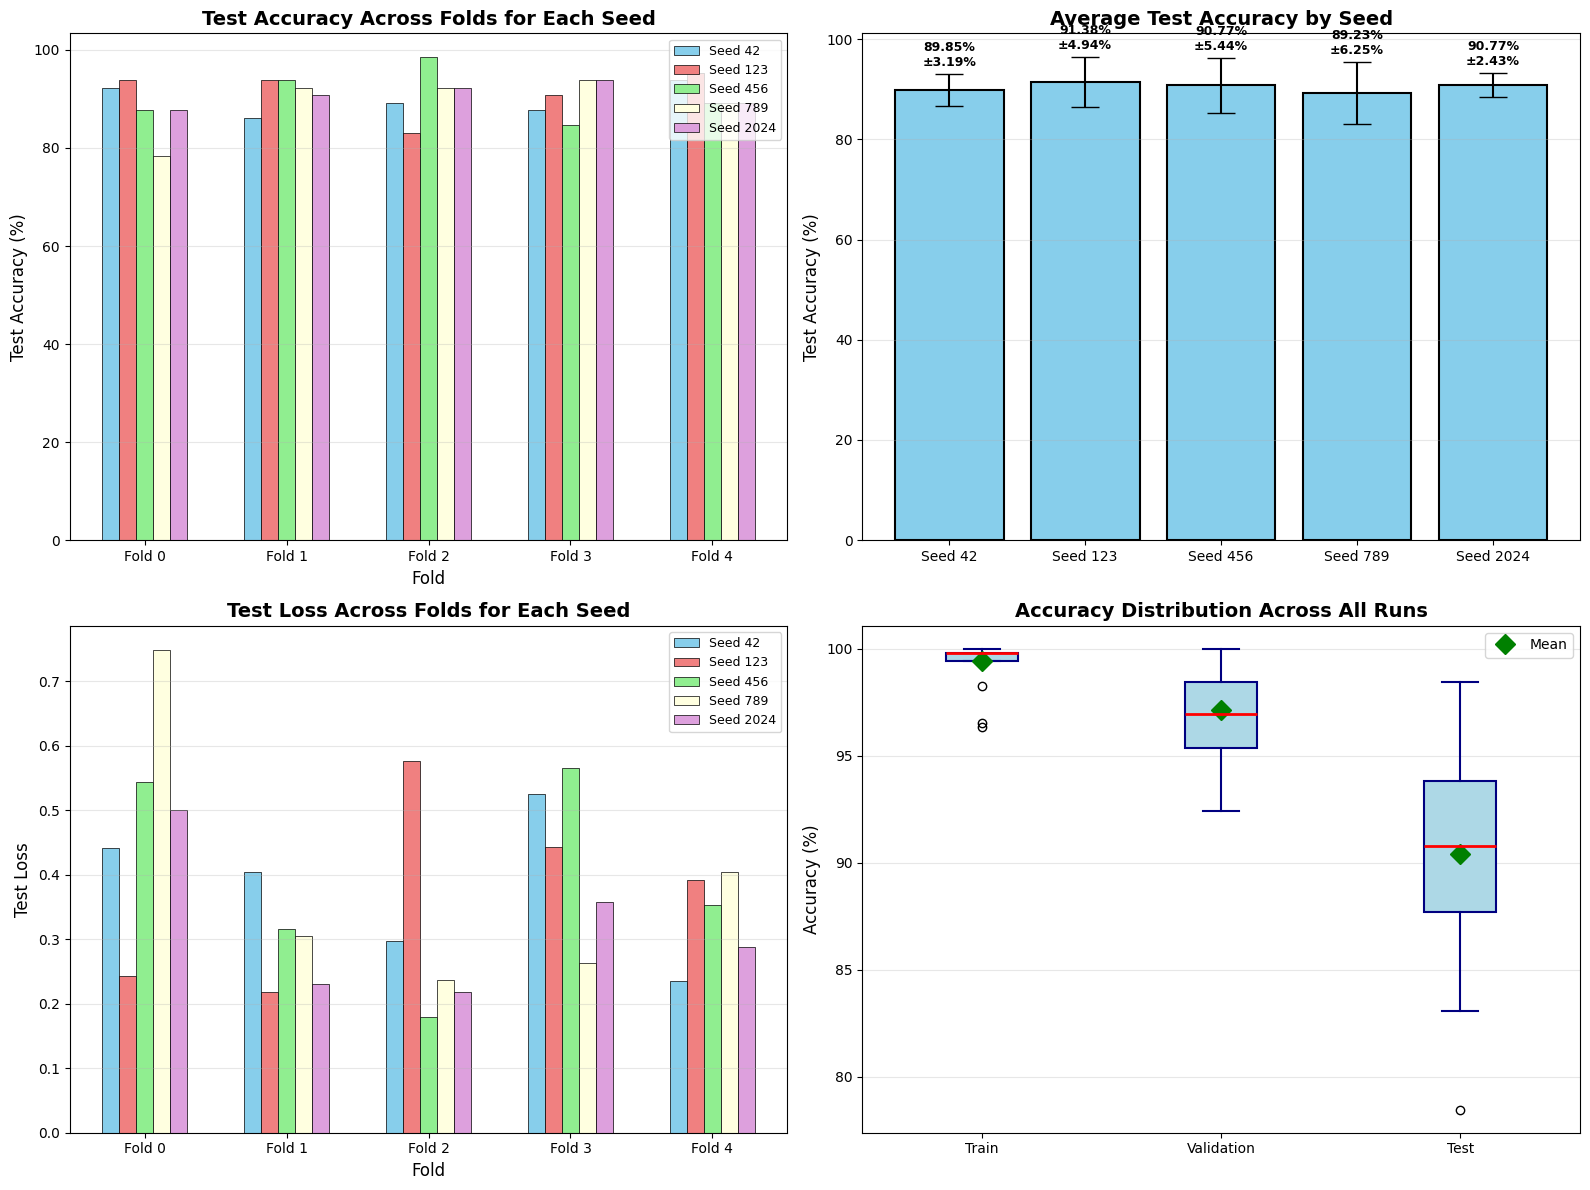


Multi-seed k-fold visualization saved as 'multi_split_results.png'


In [107]:
# Store results for all splits
all_results = {
    'seed': [],
    'fold': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': [],
    'train_loss': [],
    'val_loss': [],
    'test_loss': []
}

print("\n" + "="*70)
print(f"MULTI-SEED STRATIFIED K-FOLD TRAINING PIPELINE")
print("="*70)
print(f"Training model on {len(splits_config)} different configurations")
print(f"(5 seeds × 5 folds per seed)")
print(f"This ensures results are consistent across different seeds and folds")
print("="*70)

for split_idx, split_config in enumerate(splits_config):
    seed = split_config['seed']
    fold = split_config['fold']
    train_loader = split_config['train_loader']
    val_loader = split_config['val_loader']
    test_loader = split_config['test_loader']
    full_dataset = split_config['full_dataset']
    
    print(f"\n{'='*70}")
    print(f"TRAINING RUN {split_idx + 1}/{len(splits_config)} - SEED: {seed}, FOLD: {fold}")
    print(f"{'='*70}")
    
    # Set seed for this training run
    set_seed(seed)
    
    #--- Model, Loss, Optimizer, Scheduler ---
    best_params = {
        "initial_filters": 80,
        "dropout": 0.20796879885018393,
        "learning_rate": 0.0004313869594239175,
        "weight_decay": 0.0001560845747200455
    }

    model = ResNet1D(
        num_classes=full_dataset.num_classes,
        initial_filters=best_params['initial_filters'],
        dropout=best_params['dropout']
    ).to(DEVICE)

    # Loss function (Cross Entropy for multi-class classification)
    criterion = nn.CrossEntropyLoss()

    # Optimizer (Adam with weight decay for regularization)
    optimizer = optim.Adam(model.parameters(), lr=best_params['learning_rate'], weight_decay=best_params['weight_decay'])

    # Learning rate scheduler (reduce LR when validation loss plateaus)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=5
    )
    
    # Print model summary (only for first split to avoid spam)
    if split_idx == 0:
        print(f"\nModel architecture:")
        print(model)
        print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
        print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}\n")
    
    #--- Training Loop ---
    num_epochs = 200
    best_val_acc = 0.0
    min_val_loss = float('inf')
    patience_early_stop = 15
    epochs_no_improve = 0
    
    print(f"Starting training for seed {seed}, fold {fold}...")
    
    for epoch in range(num_epochs):
        # Train for one epoch
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        
        # Evaluate on validation set
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        
        # Update learning rate based on validation loss
        scheduler.step(val_loss)
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Save best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_resnet1d_seed{seed}_fold{fold}.pth')
        
        # Early stopping check based on validation loss
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        # Trigger early stopping
        if epochs_no_improve == patience_early_stop:
            print(f"  Early stopping at epoch {epoch+1}")
            break
    
    print(f"Training complete for seed {seed}, fold {fold}. Total epochs: {epoch + 1}")
    
    #--- Load Best Model and Evaluate on All Sets ---
    model.load_state_dict(torch.load(f'best_resnet1d_seed{seed}_fold{fold}.pth'))
    
    # Evaluate on train set
    train_loss_final, train_acc_final, _, _ = evaluate(model, train_loader, criterion, DEVICE)
    
    # Evaluate on validation set
    val_loss_final, val_acc_final, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    
    # Evaluate on test set
    test_loss_final, test_acc_final, _, _ = evaluate(model, test_loader, criterion, DEVICE)
    
    # Store results
    all_results['seed'].append(seed)
    all_results['fold'].append(fold)
    all_results['train_acc'].append(train_acc_final)
    all_results['val_acc'].append(val_acc_final)
    all_results['test_acc'].append(test_acc_final)
    all_results['train_loss'].append(train_loss_final)
    all_results['val_loss'].append(val_loss_final)
    all_results['test_loss'].append(test_loss_final)
    
    print(f"\nSeed {seed}, Fold {fold} Final Results:")
    print(f"  Train Acc: {train_acc_final:.2f}% | Val Acc: {val_acc_final:.2f}% | Test Acc: {test_acc_final:.2f}%")

#--- Calculate Average Results Across All Splits ---
print("\n" + "="*70)
print("AVERAGE RESULTS ACROSS ALL SEEDS AND FOLDS")
print("="*70)
print(f"\nTrain Accuracy: {np.mean(all_results['train_acc']):.2f}% ± {np.std(all_results['train_acc']):.2f}%")
print(f"Val Accuracy:   {np.mean(all_results['val_acc']):.2f}% ± {np.std(all_results['val_acc']):.2f}%")
print(f"Test Accuracy:  {np.mean(all_results['test_acc']):.2f}% ± {np.std(all_results['test_acc']):.2f}%")
print(f"\nTrain Loss: {np.mean(all_results['train_loss']):.4f} ± {np.std(all_results['train_loss']):.4f}")
print(f"Val Loss:   {np.mean(all_results['val_loss']):.4f} ± {np.std(all_results['val_loss']):.4f}")
print(f"Test Loss:  {np.mean(all_results['test_loss']):.4f} ± {np.std(all_results['test_loss']):.4f}")

# Create results DataFrame
results_df = pd.DataFrame(all_results)
print("\n" + "="*70)
print("DETAILED RESULTS PER SEED AND FOLD")
print("="*70)
print(results_df.to_string(index=False))

# Save results to CSV
results_df.to_csv('multi_split_results.csv', index=False)
print("\nResults saved to 'multi_split_results.csv'")

# Calculate per-seed and per-fold statistics
print("\n" + "="*70)
print("STATISTICS BY SEED")
print("="*70)
for seed in SEEDS:
    seed_data = results_df[results_df['seed'] == seed]
    print(f"\nSeed {seed}:")
    print(f"  Train Acc: {seed_data['train_acc'].mean():.2f}% ± {seed_data['train_acc'].std():.2f}%")
    print(f"  Val Acc:   {seed_data['val_acc'].mean():.2f}% ± {seed_data['val_acc'].std():.2f}%")
    print(f"  Test Acc:  {seed_data['test_acc'].mean():.2f}% ± {seed_data['test_acc'].std():.2f}%")

"""
Visualize the consistency of results across different seeds and folds.
This helps verify that improvements are real and not due to lucky splits.
"""

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy comparison - organized by seed
ax1 = axes[0, 0]
unique_seeds = sorted(results_df['seed'].unique())
fold_range = range(5)
width = 0.12
colors = ['skyblue', 'lightcoral', 'lightgreen', 'lightyellow', 'plum']

for idx, seed in enumerate(unique_seeds):
    seed_data = results_df[results_df['seed'] == seed]
    x_pos = np.arange(5) + idx * width
    ax1.bar(x_pos, seed_data['test_acc'].values, width, label=f'Seed {seed}', color=colors[idx], edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Fold', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Test Accuracy Across Folds for Each Seed', fontsize=14, fontweight='bold')
ax1.set_xticks(np.arange(5) + width * 2)
ax1.set_xticklabels([f'Fold {i}' for i in range(5)])
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Average accuracy per seed with error bars
ax2 = axes[0, 1]
seed_means = [results_df[results_df['seed'] == seed]['test_acc'].mean() for seed in unique_seeds]
seed_stds = [results_df[results_df['seed'] == seed]['test_acc'].std() for seed in unique_seeds]
seed_labels = [f'Seed {s}' for s in unique_seeds]

bars = ax2.bar(seed_labels, seed_means, yerr=seed_stds, capsize=10, color='skyblue', edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Average Test Accuracy by Seed', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, mean, std in zip(bars, seed_means, seed_stds):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + std + 1,
            f'{mean:.2f}%\n±{std:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Loss comparison across seeds and folds
ax3 = axes[1, 0]
for idx, seed in enumerate(unique_seeds):
    seed_data = results_df[results_df['seed'] == seed]
    x_pos = np.arange(5) + idx * width
    ax3.bar(x_pos, seed_data['test_loss'].values, width, label=f'Seed {seed}', color=colors[idx], edgecolor='black', linewidth=0.5)

ax3.set_xlabel('Fold', fontsize=12)
ax3.set_ylabel('Test Loss', fontsize=12)
ax3.set_title('Test Loss Across Folds for Each Seed', fontsize=14, fontweight='bold')
ax3.set_xticks(np.arange(5) + width * 2)
ax3.set_xticklabels([f'Fold {i}' for i in range(5)])
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Train vs Val vs Test accuracy distribution (boxplot)
ax4 = axes[1, 1]
ax4.boxplot([all_results['train_acc'], all_results['val_acc'], all_results['test_acc']], 
            labels=['Train', 'Validation', 'Test'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', edgecolor='navy', linewidth=1.5),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='navy', linewidth=1.5),
            capprops=dict(color='navy', linewidth=1.5))

ax4.set_ylabel('Accuracy (%)', fontsize=12)
ax4.set_title('Accuracy Distribution Across All Runs', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Add mean markers
for i, (label, data) in enumerate(zip(['Train', 'Val', 'Test'], 
                                       [all_results['train_acc'], all_results['val_acc'], all_results['test_acc']])):
    mean_val = np.mean(data)
    ax4.plot(i+1, mean_val, 'D', markersize=10, color='green', label='Mean' if i == 0 else '')

ax4.legend()

plt.tight_layout()
plt.savefig('multi_split_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMulti-seed k-fold visualization saved as 'multi_split_results.png'")

In [108]:
# #--- Training loop ---
# num_epochs = 100
# best_val_acc = 0.0
# train_losses = []
# val_losses = []
# train_accs = []
# val_accs = []
# patience = 15
# epochs_no_improve = 0
# min_val_loss = float('inf')

# print("\nStarting training...")
# for epoch in range(num_epochs):
#     # Train for one epoch
#     train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    
#     # Evaluate on validation set
#     val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    
#     # Update learning rate based on validation loss
#     scheduler.step(val_loss)
    
#     # Store metrics
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     train_accs.append(train_acc)
#     val_accs.append(val_acc)
    
#     # Print progress
#     print(f"Epoch [{epoch+1}/{num_epochs}] "
#           f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
#           f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
#     # Save best model
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         torch.save(model.state_dict(), 'best_resnet1d_shark.pth')
#         print(f"  -> New best model saved!")

#     # Early stopping
#     if val_loss < min_val_loss:
#         min_val_loss = val_loss
#         epochs_no_improve = 0
#     else:
#         epochs_no_improve += 1

#     if epochs_no_improve == patience:
#         print(f"\nEarly stopping triggered after {epoch+1} epochs")
#         print(f"No improvement for {patience} consecutive epochs")
#         break

# print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.2f}%")
# print(f"Total epochs trained: {len(train_losses)}")

In [109]:
#--- Optional: Evaluation on specific seed/fold combination ---
# Example: Load a specific seed and fold to analyze
seed_to_use = 42
fold_to_use = 0

print(f"\nLoading model for Seed {seed_to_use}, Fold {fold_to_use}...")

# Find the split config for this seed and fold
specific_split_config = None
for config in splits_config:
    if config['seed'] == seed_to_use and config['fold'] == fold_to_use:
        specific_split_config = config
        break

if specific_split_config is None:
    print(f"Error: Could not find configuration for Seed {seed_to_use}, Fold {fold_to_use}")
else:
    # Get the dataset and loaders
    full_dataset = specific_split_config['full_dataset']
    test_loader = specific_split_config['test_loader']
    
    # Load the model
    model = ResNet1D(num_classes=full_dataset.num_classes, 
                     initial_filters=80, 
                     dropout=0.20796879885018393).to(DEVICE)
    model.load_state_dict(torch.load(f'best_resnet1d_seed{seed_to_use}_fold{fold_to_use}.pth'))
    
    criterion = nn.CrossEntropyLoss()
    
    # Evaluate on test set
    test_loss, test_acc, test_predictions, test_labels = evaluate(
        model, test_loader, criterion, DEVICE
    )
    
    print(f"\n{'='*60}")
    print(f"TEST SET RESULTS - Seed {seed_to_use}, Fold {fold_to_use}")
    print(f"{'='*60}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print(f"\nClassification Report:")
    
    # Get unique labels that actually appear in test set
    unique_labels = sorted(list(set(test_labels)))
    target_names_test = [full_dataset.label_encoder.classes_[i] for i in unique_labels]
    print(classification_report(
        test_labels, 
        test_predictions,
        labels=unique_labels,
        target_names=target_names_test
    ))


Loading model for Seed 42, Fold 0...

TEST SET RESULTS - Seed 42, Fold 0
Test Loss: 0.4412
Test Accuracy: 92.31%

Classification Report:
                           precision    recall  f1-score   support

     Arabian smooth-hound       1.00      1.00      1.00         2
 Atlantic Sharpnose shark       1.00      1.00      1.00         1
     Blackchin guitarfish       1.00      1.00      1.00         1
          Blacknose shark       1.00      0.50      0.67         2
Blackspotted smooth-hound       0.00      0.00      0.00         1
      Blacktip reef shark       1.00      1.00      1.00         1
           Blacktip shark       0.86      1.00      0.92         6
               Blue shark       1.00      1.00      1.00         7
         Bonnethead shark       1.00      1.00      1.00         1
      Bowmouth guitarfish       1.00      1.00      1.00         2
 Brownbanded bamboo shark       1.00      1.00      1.00         1
               Bull shark       1.00      1.00      1.00 

In [110]:
#--- Load and Analyze Best Model Across All Runs ---
best_run_idx = np.argmax(all_results['test_acc'])
best_seed = all_results['seed'][best_run_idx]
best_fold = all_results['fold'][best_run_idx]

print(f"\n{'='*70}")
print(f"LOADING BEST MODEL ACROSS ALL 25 RUNS")
print(f"{'='*70}")
print(f"Best configuration: Seed {best_seed}, Fold {best_fold}")
print(f"Test Accuracy: {all_results['test_acc'][best_run_idx]:.2f}%")
print(f"{'='*70}")

# Find the split config for this seed and fold
best_split_config = None
for config in splits_config:
    if config['seed'] == best_seed and config['fold'] == best_fold:
        best_split_config = config
        break

if best_split_config is None:
    print("Error: Could not find matching split configuration")
else:
    # Get the dataset and loaders
    full_dataset = best_split_config['full_dataset']
    test_loader = best_split_config['test_loader']
    
    # Load the best model
    model = ResNet1D(num_classes=full_dataset.num_classes, 
                     initial_filters=80, 
                     dropout=0.20796879885018393).to(DEVICE)
    model.load_state_dict(torch.load(f'best_resnet1d_seed{best_seed}_fold{best_fold}.pth'))
    
    criterion = nn.CrossEntropyLoss()
    
    # Evaluate on test set
    test_loss, test_acc, test_predictions, test_labels = evaluate(
        model, test_loader, criterion, DEVICE
    )
    
    print(f"\n{'='*60}")
    print(f"BEST MODEL TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print(f"\nClassification Report:")
    
    # Get unique labels that actually appear in test set
    unique_labels = sorted(list(set(test_labels)))
    target_names_test = [full_dataset.label_encoder.classes_[i] for i in unique_labels]
    print(classification_report(
        test_labels, 
        test_predictions,
        labels=unique_labels,
        target_names=target_names_test
    ))


LOADING BEST MODEL ACROSS ALL 25 RUNS
Best configuration: Seed 456, Fold 2
Test Accuracy: 98.46%

BEST MODEL TEST SET RESULTS
Test Loss: 0.1796
Test Accuracy: 98.46%

Classification Report:
                           precision    recall  f1-score   support

     Arabian smooth-hound       1.00      1.00      1.00         1
 Atlantic Sharpnose shark       1.00      1.00      1.00         1
     Blackchin guitarfish       1.00      1.00      1.00         2
          Blacknose shark       1.00      1.00      1.00         1
Blackspotted smooth-hound       1.00      1.00      1.00         1
      Blacktip reef shark       1.00      1.00      1.00         2
           Blacktip shark       1.00      1.00      1.00         6
               Blue shark       1.00      1.00      1.00         7
         Bonnethead shark       1.00      1.00      1.00         1
      Bowmouth guitarfish       1.00      1.00      1.00         1
 Brownbanded bamboo shark       1.00      1.00      1.00         2
    

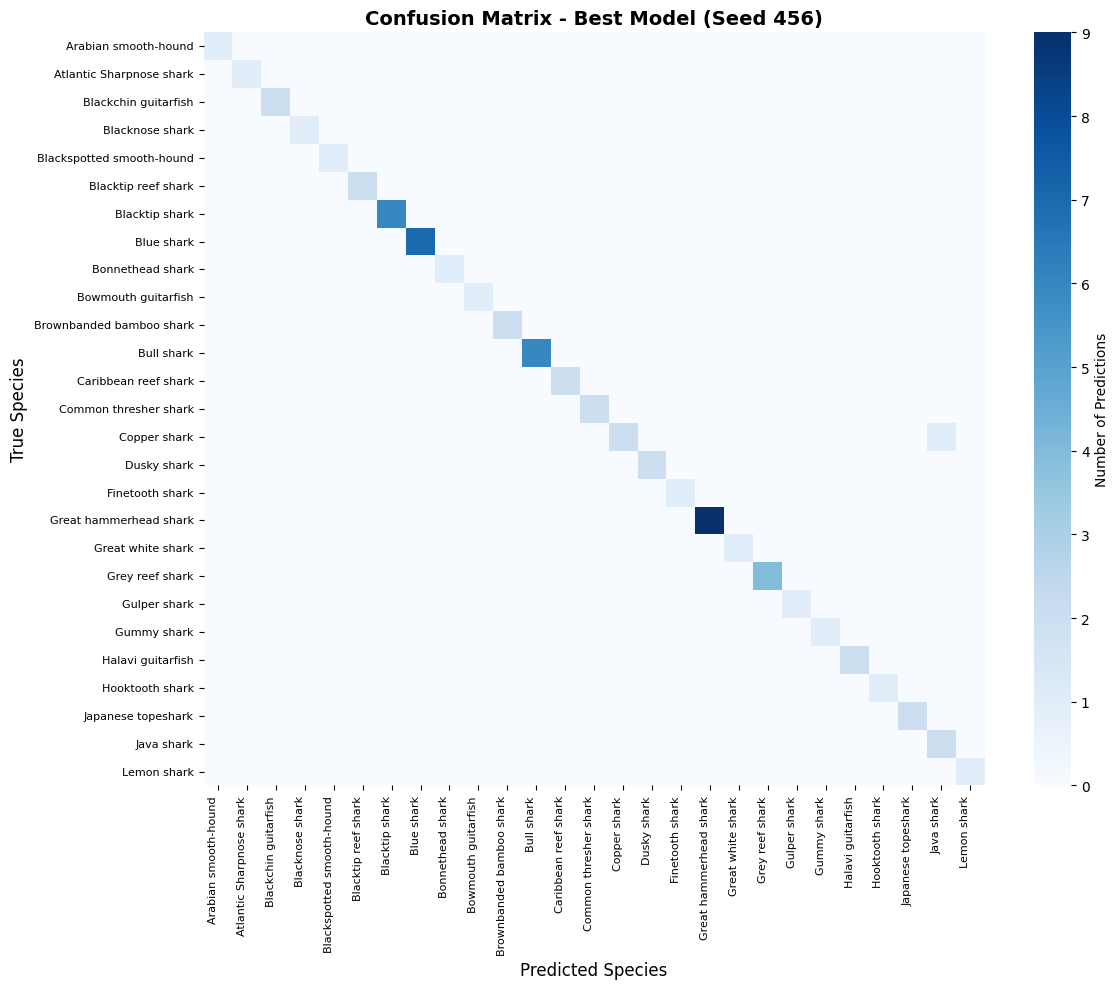

Confusion matrix saved as 'confusion_matrix.png'


In [111]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get confusion matrix for test set
cm = confusion_matrix(test_labels, test_predictions)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=target_names_test, 
            yticklabels=target_names_test,
            cbar_kws={'label': 'Number of Predictions'})
plt.xlabel('Predicted Species', fontsize=12)
plt.ylabel('True Species', fontsize=12)
plt.title(f'Confusion Matrix - Best Model (Seed {best_seed})', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'confusion_matrix.png'")


TOP 5 BEST PERFORMING SPECIES
                  Species  F1-Score  Precision  Recall  Support
     Arabian smooth-hound       1.0        1.0     1.0        1
 Atlantic Sharpnose shark       1.0        1.0     1.0        1
     Blackchin guitarfish       1.0        1.0     1.0        2
          Blacknose shark       1.0        1.0     1.0        1
Blackspotted smooth-hound       1.0        1.0     1.0        1

BOTTOM 5 WORST PERFORMING SPECIES
           Species  F1-Score  Precision   Recall  Support
 Halavi guitarfish       1.0   1.000000 1.000000        2
       Lemon shark       1.0   1.000000 1.000000        1
Japanese topeshark       1.0   1.000000 1.000000        2
      Copper shark       0.8   1.000000 0.666667        3
        Java shark       0.8   0.666667 1.000000        2


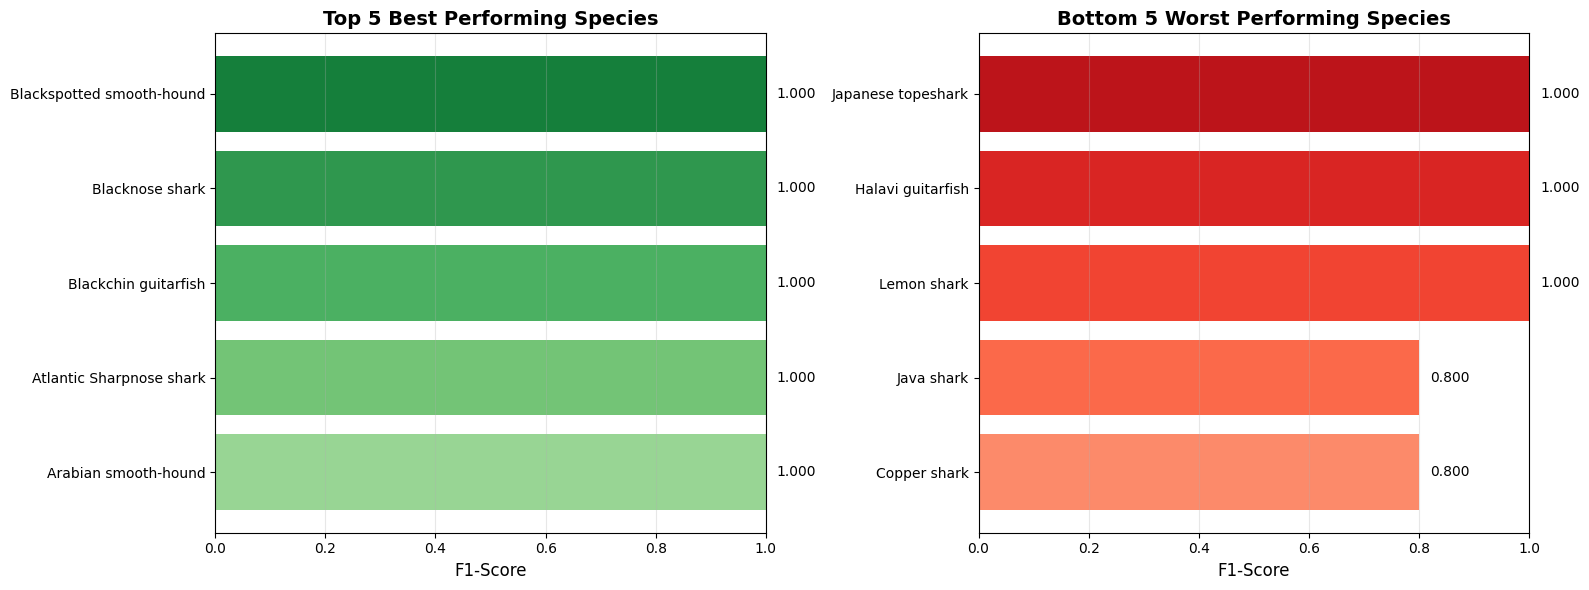


Species performance plot saved as 'species_performance.png'


In [112]:
from sklearn.metrics import precision_recall_fscore_support

# Calculate per-class metrics (precision, recall, f1-score)
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, 
    test_predictions, 
    labels=unique_labels,
    zero_division=0
)

# Create dataframe with species performance
species_performance = pd.DataFrame({
    'Species': target_names_test,
    'F1-Score': f1,
    'Precision': precision,
    'Recall': recall,
    'Support': support
})

# Sort by F1-score
species_performance = species_performance.sort_values('F1-Score', ascending=False)

# Get top 5 and bottom 5
top_5 = species_performance.head(5)
bottom_5 = species_performance.tail(5)

print("\n" + "="*70)
print("TOP 5 BEST PERFORMING SPECIES")
print("="*70)
print(top_5.to_string(index=False))

print("\n" + "="*70)
print("BOTTOM 5 WORST PERFORMING SPECIES")
print("="*70)
print(bottom_5.to_string(index=False))

# Plot top 5 and bottom 5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 5
top_5_sorted = top_5.sort_values('F1-Score', ascending=True)
colors_top = plt.cm.Greens(np.linspace(0.4, 0.8, len(top_5_sorted)))
ax1.barh(range(len(top_5_sorted)), top_5_sorted['F1-Score'], color=colors_top)
ax1.set_yticks(range(len(top_5_sorted)))
ax1.set_yticklabels(top_5_sorted['Species'], fontsize=10)
ax1.set_xlabel('F1-Score', fontsize=12)
ax1.set_title('Top 5 Best Performing Species', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(top_5_sorted['F1-Score']):
    ax1.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10)

# Bottom 5
bottom_5_sorted = bottom_5.sort_values('F1-Score', ascending=True)
colors_bottom = plt.cm.Reds(np.linspace(0.4, 0.8, len(bottom_5_sorted)))
ax2.barh(range(len(bottom_5_sorted)), bottom_5_sorted['F1-Score'], color=colors_bottom)
ax2.set_yticks(range(len(bottom_5_sorted)))
ax2.set_yticklabels(bottom_5_sorted['Species'], fontsize=10)
ax2.set_xlabel('F1-Score', fontsize=12)
ax2.set_title('Bottom 5 Worst Performing Species', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(bottom_5_sorted['F1-Score']):
    ax2.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('species_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSpecies performance plot saved as 'species_performance.png'")